## Imports and dataset loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import seaborn as sns
import time, random

from scipy import stats
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo
from torchvision import datasets

from spectral_clustering.metrics.clustering import clustering_scores, run_iters, bar_comparison, calculate_neighbourhood_purity, summarise, clustering_accuracy
from spectral_clustering.graphs import knn_graph, fully_connected, adaptive_neighbour_graph_can, epsilon_graph,  compute_biclique_kr
from spectral_clustering.models.spectral import BaseSpectralClustering, PCAN

iris = fetch_ucirepo(id=53)
iris_labels = pd.Categorical(iris['data']['targets']['class'], categories=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], ordered=True).codes

wine = fetch_ucirepo(id=109)
wine_labels = wine['data']['targets']['class'] - 1
wine_labels = np.array(wine_labels, dtype=int)

seeds = pd.read_csv('datasets/seeds_dataset.csv', header=None)
seeds_labels = seeds.iloc[:, -1].values - 1
seeds_labels = np.array(seeds_labels, dtype=int)

breast_cancer = fetch_ucirepo(id=17)
breast_cancer_labels = pd.Categorical(breast_cancer['data']['targets']['Diagnosis'], categories=['M', 'B'], ordered=True).codes

def z_score_normalization(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

iris_normalized = z_score_normalization(iris['data']['features'])
iris = np.array(iris_normalized, dtype=float)

wine_normalized = z_score_normalization(wine['data']['features'])
wine = np.array(wine_normalized, dtype=float)

seeds_normalized = z_score_normalization(seeds.drop(columns=seeds.columns[-1]))
seeds = np.array(seeds_normalized, dtype=float)

breast_cancer_normalized = z_score_normalization(breast_cancer['data']['features'])
breast_cancer = np.array(breast_cancer_normalized, dtype=float)

def balanced_subset(labels, per_class=50, seed=0):
    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    idx = np.concatenate([
        rng.choice(np.where(labels == c)[0], size=per_class, replace=False)
        for c in classes
    ])
    return idx

MNIST = datasets.MNIST(root='data', train=True, download=False)
MNIST_labels = MNIST.targets.numpy()
MNIST = MNIST.data.numpy().reshape(-1, 28*28) / 255.0

subset_idx = balanced_subset(MNIST_labels, per_class=200, seed=0)
MNIST = MNIST[subset_idx]
MNIST_labels = MNIST_labels[subset_idx]

dataset_names = ['iris', 'wine', 'seeds', 'breast_cancer', 'mnist']
dataset_objs = [iris, wine, seeds, breast_cancer, MNIST]
labels_objs = [iris_labels, wine_labels, seeds_labels, breast_cancer_labels, MNIST_labels]

In [2]:
plt.rcParams.update({
    # --- Font ---
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}',

    # --- Font sizes ---
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,   # was 11
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,

    # --- Figure ---
    'figure.figsize': (7, 4.2),
    'figure.dpi': 300,
    'figure.facecolor': 'white',

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'axes.grid': False,

    # --- Grid ---
    'grid.color': '0.85',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,

    # --- Ticks ---
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,

    # --- Lines ---
    'lines.linewidth': 1.5,

    # --- Legend ---
    'legend.frameon': False,

    # --- Savefig ---
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

COLORS = {
    'raw': '#666666',
    'vae': '#0072B2',
    'simclr': '#009E73',
    'simclr_pca': '#D55E00',

    # graph-building methods
    'knn': '#666666',
    'fc': '#0072B2',
    'adaptive': '#009E73',
    'biclique': '#D55E00',
    'pcan': '#CC79A7',
}

## Plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, Colormap
from scipy import sparse

TWO_CLASS_CMAP = ListedColormap(["#0072B2", "#D55E00"])


def plot_graph_from_adjacency(
    W,
    X,
    labels=None,
    filename=None,
    undirected=True,
    edge_threshold=0.0,
    max_edges=None,
    legend=True,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    node_size=28,
    node_alpha=0.95,
    node_edgecolor="black",
    node_edgewidth=0.45,
    edge_alpha=0.22,
    edge_linewidth=0.55,
    scale_edge_width_by_weight=False,
    cmap=TWO_CLASS_CMAP,
    node_color="#0072B2",
    edge_color="#B0B0B0",
    legend_ncol=None,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.12),
    edge_width_min_scale=0.25,
    edge_width_max_scale=3.5,
    edge_width_power=1.6,
    ax=None,
):
    X = np.asarray(X)
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError(f"X must have shape (n, 2), got {X.shape}")

    n = X.shape[0]

    # Extract edges
    if sparse.issparse(W):
        if W.shape != (n, n):
            raise ValueError(f"W must have shape ({n}, {n}), got {W.shape}")
        W_plot = W.tocoo(copy=True)
        mask = W_plot.data > edge_threshold
        rows = W_plot.row[mask]
        cols = W_plot.col[mask]
        vals = W_plot.data[mask]
    else:
        W = np.asarray(W)
        if W.shape != (n, n):
            raise ValueError(f"W must have shape ({n}, {n}), got {W.shape}")
        rows, cols = np.nonzero(W > edge_threshold)
        vals = W[rows, cols]

    # Remove self-loops
    keep = rows != cols
    rows, cols, vals = rows[keep], cols[keep], vals[keep]

    # For undirected graphs, keep only upper triangle
    if undirected:
        keep = rows < cols
        rows, cols, vals = rows[keep], cols[keep], vals[keep]

    if vals.size == 0:
        raise ValueError("No edges remain after applying edge filtering.")

    # Keep only strongest edges
    if max_edges is not None and vals.size > max_edges:
        idx = np.argsort(vals)[-max_edges:]
        rows, cols, vals = rows[idx], cols[idx], vals[idx]

    segments = np.stack([X[rows], X[cols]], axis=1)

    if scale_edge_width_by_weight and vals.size > 0:
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            scaled = (vals - vmin) / (vmax - vmin)

            # make strong edges stand out more
            scaled = scaled ** edge_width_power

            linewidths = edge_linewidth * (
                edge_width_min_scale
                + (edge_width_max_scale - edge_width_min_scale) * scaled
            )
        else:
            linewidths = np.full(vals.shape, edge_linewidth, dtype=float)
    else:
        linewidths = np.full(vals.shape, edge_linewidth, dtype=float)

    # Plot
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)
    else:
        fig = ax.figure

    lc = LineCollection(
        segments,
        colors=edge_color,
        linewidths=linewidths,
        alpha=edge_alpha,
        zorder=1,
    )
    ax.add_collection(lc)

    if labels is None:
        ax.scatter(
            X[:, 0],
            X[:, 1],
            s=node_size,
            c=node_color,
            edgecolors=node_edgecolor,
            linewidths=node_edgewidth,
            alpha=node_alpha,
            zorder=2,
        )
    else:
        labels = np.asarray(labels)
        if labels.shape[0] != n:
            raise ValueError(f"labels must have length {n}, got {labels.shape[0]}")

        unique_labels = np.unique(labels)

        if isinstance(cmap, Colormap):
            cmap_obj = cmap
        else:
            cmap_obj = plt.get_cmap(cmap, len(unique_labels))

        for i, lab in enumerate(unique_labels):
            mask = labels == lab
            if isinstance(cmap_obj, ListedColormap):
                colour = cmap_obj.colors[i % len(cmap_obj.colors)]
            else:
                denom = max(len(unique_labels) - 1, 1)
                colour = cmap_obj(i / denom)

            ax.scatter(
                X[mask, 0],
                X[mask, 1],
                s=node_size,
                color=colour,
                edgecolors=node_edgecolor,
                linewidths=node_edgewidth,
                alpha=node_alpha,
                zorder=2,
                label=str(lab),
            )

        if legend:
            if legend_ncol is None:
                legend_ncol = min(len(unique_labels), 5)

            ax.legend(
                loc=legend_loc,
                bbox_to_anchor=legend_bbox_to_anchor,
                ncol=legend_ncol,
                frameon=False,
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.set_axisbelow(True)
    ax.set_aspect("equal", adjustable="box")

    if not xticks:
        ax.set_xticks([])
    if not yticks:
        ax.set_yticks([])

    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    x_pad = 0.05 * max(x_max - x_min, 1e-12)
    y_pad = 0.05 * max(y_max - y_min, 1e-12)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    if created_fig:
        fig.tight_layout()
        if filename is not None:
            fig.savefig(f"charts/{filename}.pdf", bbox_inches="tight")
            fig.savefig(f"charts/{filename}.png", bbox_inches="tight")
        plt.show()

    return fig, ax

In [ ]:
from sklearn.datasets import make_moons
from spectral_clustering.graphs.constructors import knn_graph, fully_connected, adaptive_neighbour_graph_can

X, y = make_moons(n_samples=100, noise=0.1, shuffle=False, random_state=13)
W_knn = knn_graph(X, k=5)
W_adap = adaptive_neighbour_graph_can(X, k=10)
W_fc = fully_connected(X)

spectral = BaseSpectralClustering(2)
labels_knn = spectral.fit_predict(W_knn)
labels_adap = spectral.fit_predict(W_adap)
labels_fc = spectral.fit_predict(W_fc)

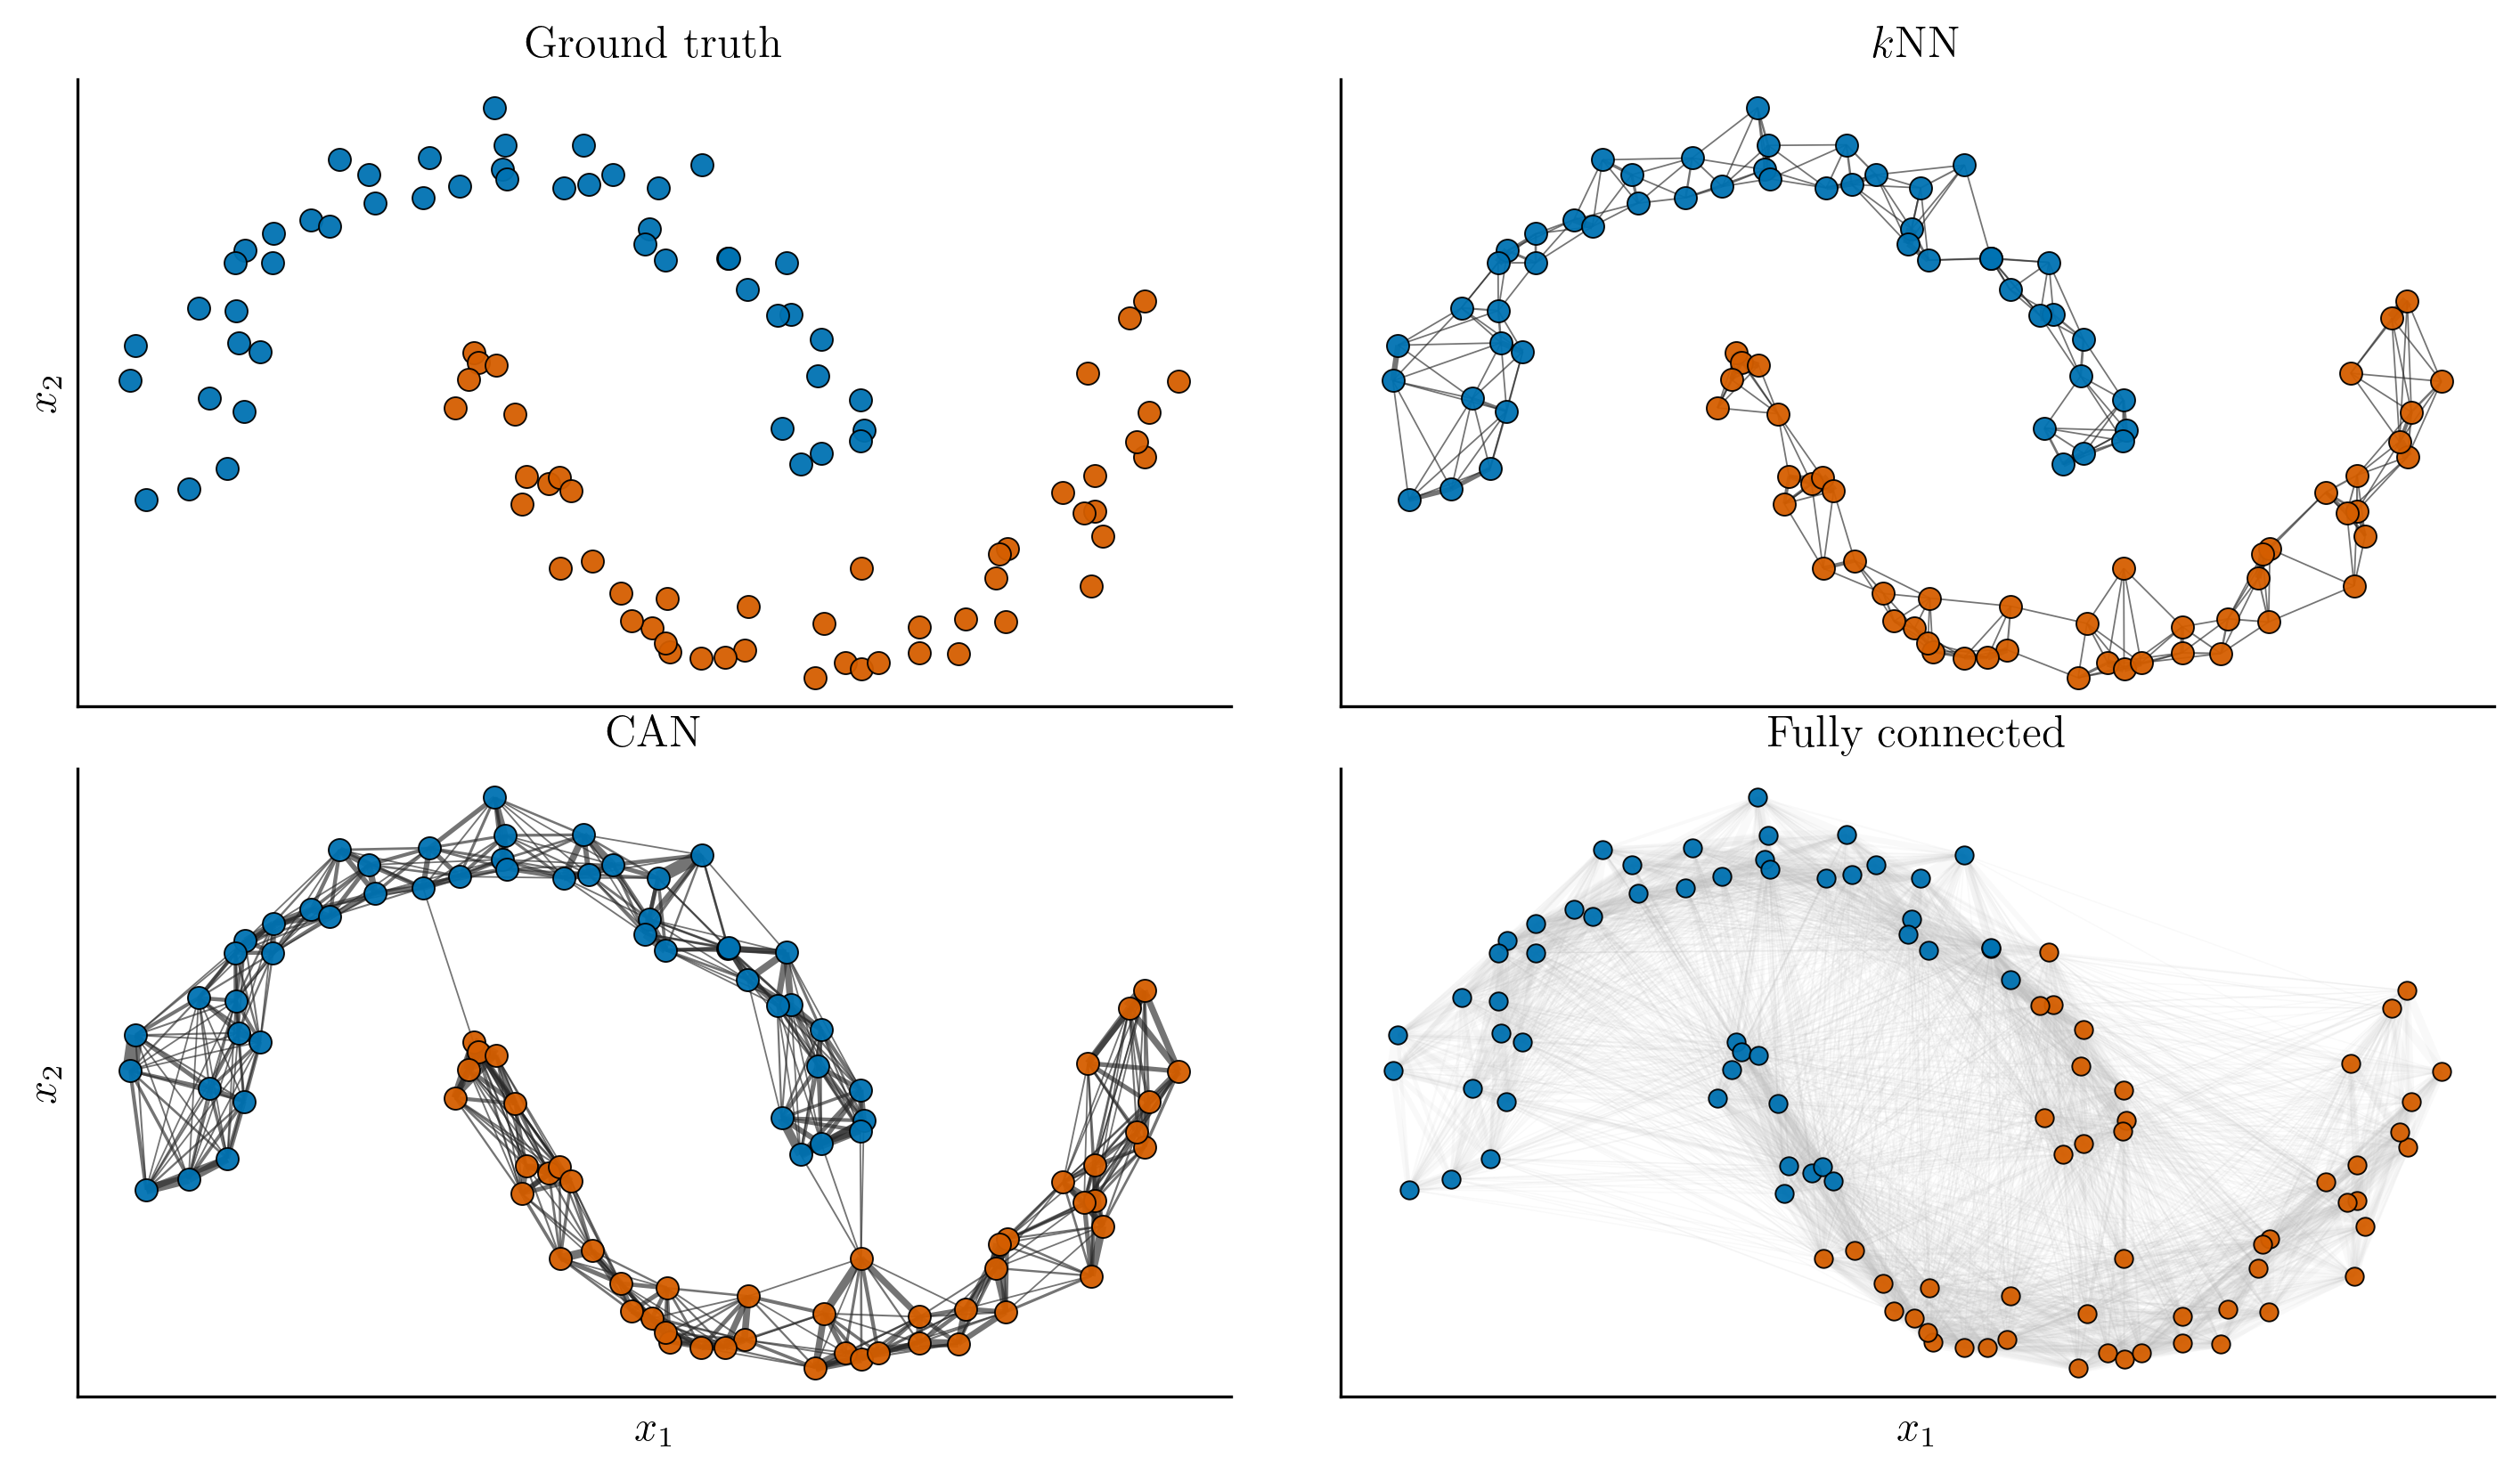

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.8), dpi=300)
axes = axes.ravel()

fig.patch.set_facecolor('white')
for ax in axes: ax.set_facecolor('white')

plot_graph_from_adjacency(
    W=W_knn,
    X=X,
    labels=y,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#C0C0C0",
    edge_alpha=0,
    node_size=36,
    scale_edge_width_by_weight=True,
    ax=axes[0],
)

plot_graph_from_adjacency(
    W=W_knn,
    X=X,
    labels=1-labels_knn,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#2A2A2A",
    edge_alpha=0.65,
    node_size=36,
    scale_edge_width_by_weight=True,
    edge_linewidth=0.85,
    edge_width_min_scale=0.5,
    edge_width_max_scale=5.0,
    edge_width_power=3,
    ax=axes[1]
)

plot_graph_from_adjacency(
    W=W_adap,
    X=X,
    labels=labels_adap,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#2A2A2A",
    edge_alpha=0.65,
    edge_linewidth=0.85,
    node_size=36,
    scale_edge_width_by_weight=True,
    edge_width_min_scale=0.5,
    edge_width_max_scale=5.0,
    edge_width_power=3,
    ax=axes[2]
)

plot_graph_from_adjacency(
    W=W_fc,
    X=X,
    labels=1-labels_fc,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#B8B8B8",
    edge_alpha=0.08,
    max_edges=3000,
    node_size=24,
    scale_edge_width_by_weight=True,
    edge_linewidth=0.7,
    edge_width_min_scale=0.5,
    edge_width_max_scale=5.0,
    edge_width_power=3,
    ax=axes[3]
)

# Titles
axes[0].set_title("Ground truth")
axes[1].set_title(r"$k$NN")
axes[2].set_title("CAN")
axes[3].set_title("Fully connected")

# Only bottom row gets x labels
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel(r"$x_1$")
axes[3].set_xlabel(r"$x_1$")

# Only left column gets y labels
axes[0].set_ylabel(r"$x_2$")
axes[1].set_ylabel("")
axes[2].set_ylabel(r"$x_2$")
axes[3].set_ylabel("")

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.08,
    top=0.93,
    wspace=0.08,
    hspace=0.10,
)

plt.savefig(f"charts/graph_construction/graph_constructions_tm.pdf", bbox_inches="tight")
plt.savefig(f"charts/graph_construction/graph_constructions_tm.png", bbox_inches="tight")

plt.show()

In [36]:
from sklearn.cluster import KMeans

km = KMeans(2)
labels_km = km.fit_predict(X)

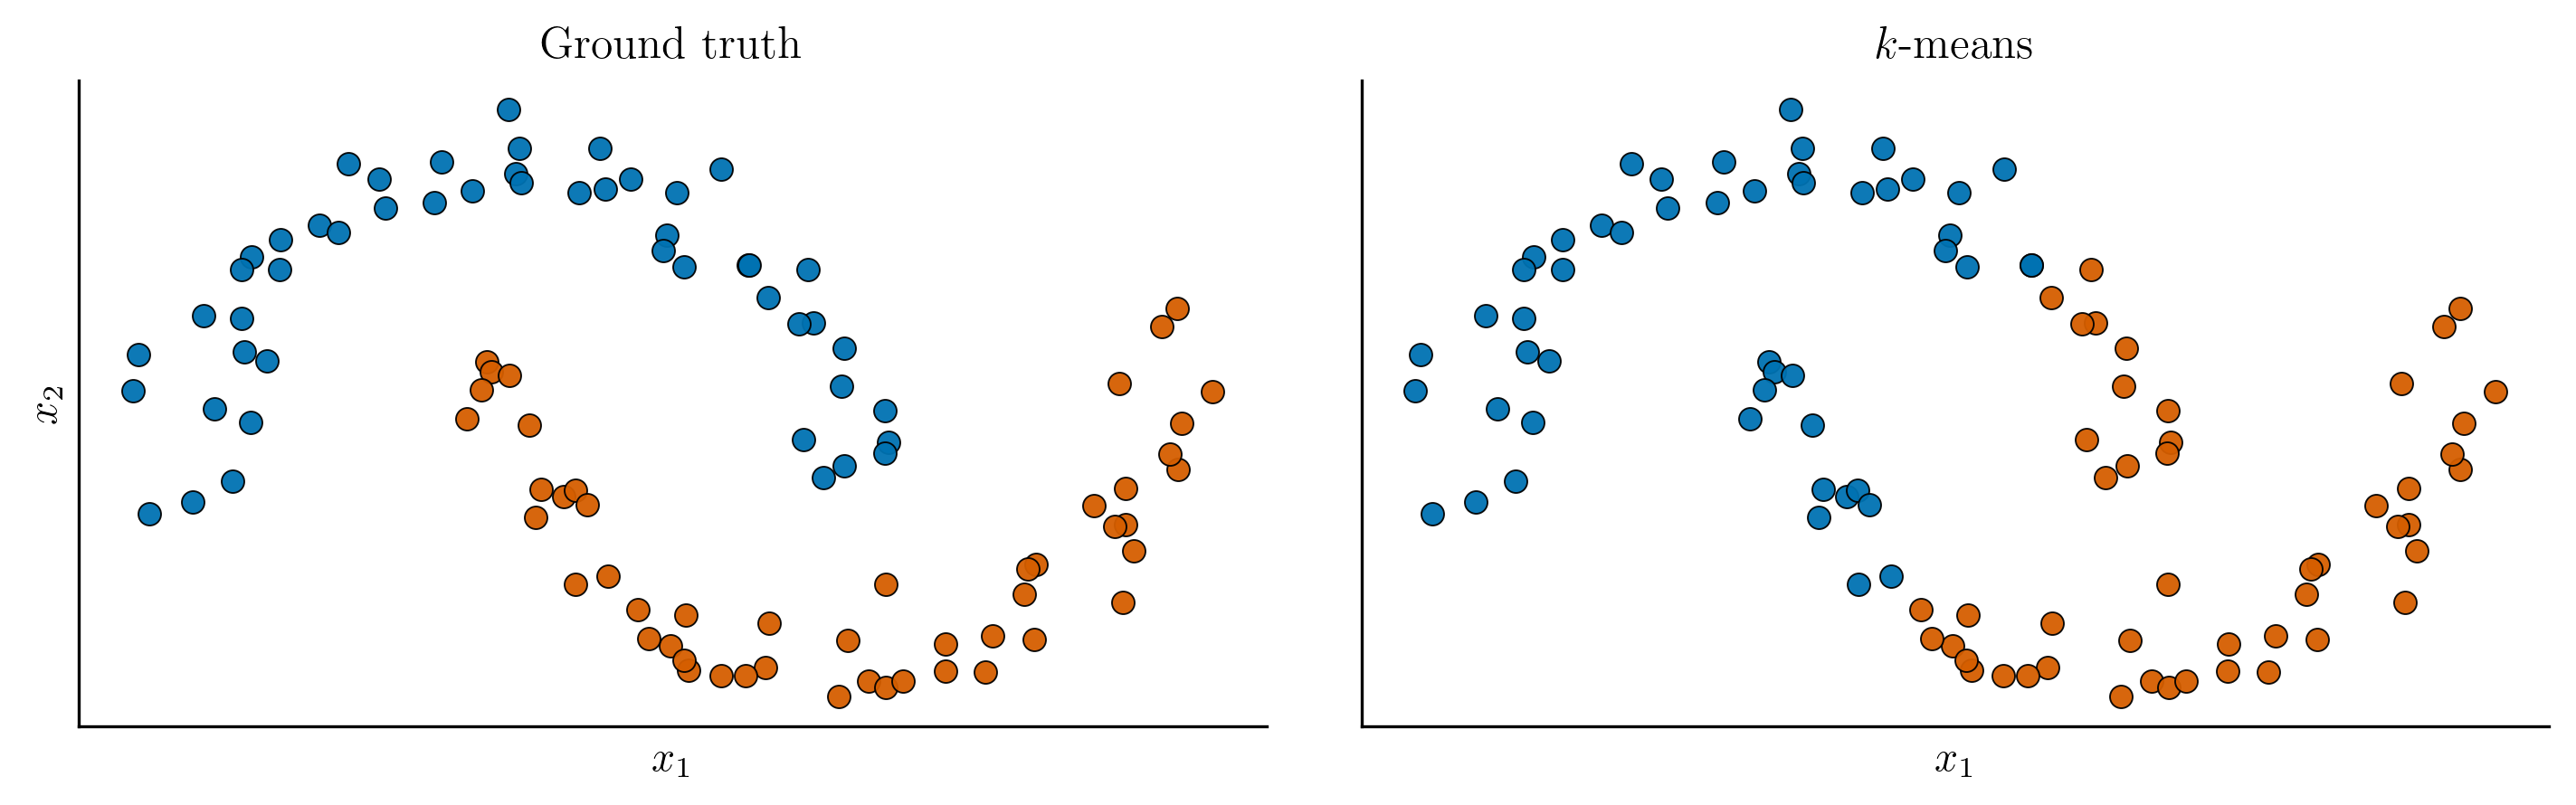

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5.8), dpi=300)
axes = axes.ravel()

fig.patch.set_facecolor('white')
for ax in axes: ax.set_facecolor('white')

plot_graph_from_adjacency(
    W=W_knn,
    X=X,
    labels=y,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#C0C0C0",
    edge_alpha=0,
    node_size=36,
    scale_edge_width_by_weight=True,
    ax=axes[0],
)

plot_graph_from_adjacency(
    W=W_knn,
    X=X,
    labels=1-labels_km,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#C0C0C0",
    edge_alpha=0,
    node_size=36,
    scale_edge_width_by_weight=True,
    ax=axes[1],
)

# Titles
axes[0].set_title("Ground truth")
axes[1].set_title(r"$k$-means")

# Only bottom row gets x labels
axes[0].set_xlabel(r"$x_1$")
axes[1].set_xlabel(r"$x_1$")

# Only left column gets y labels
axes[0].set_ylabel(r"$x_2$")
axes[1].set_ylabel("")

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.08,
    top=0.93,
    wspace=0.08,
    hspace=0.10,
)

plt.savefig(f"charts/graph_construction/tm_kmeans.pdf", bbox_inches="tight")
plt.savefig(f"charts/graph_construction/tm_kmeans.png", bbox_inches="tight")

plt.show()

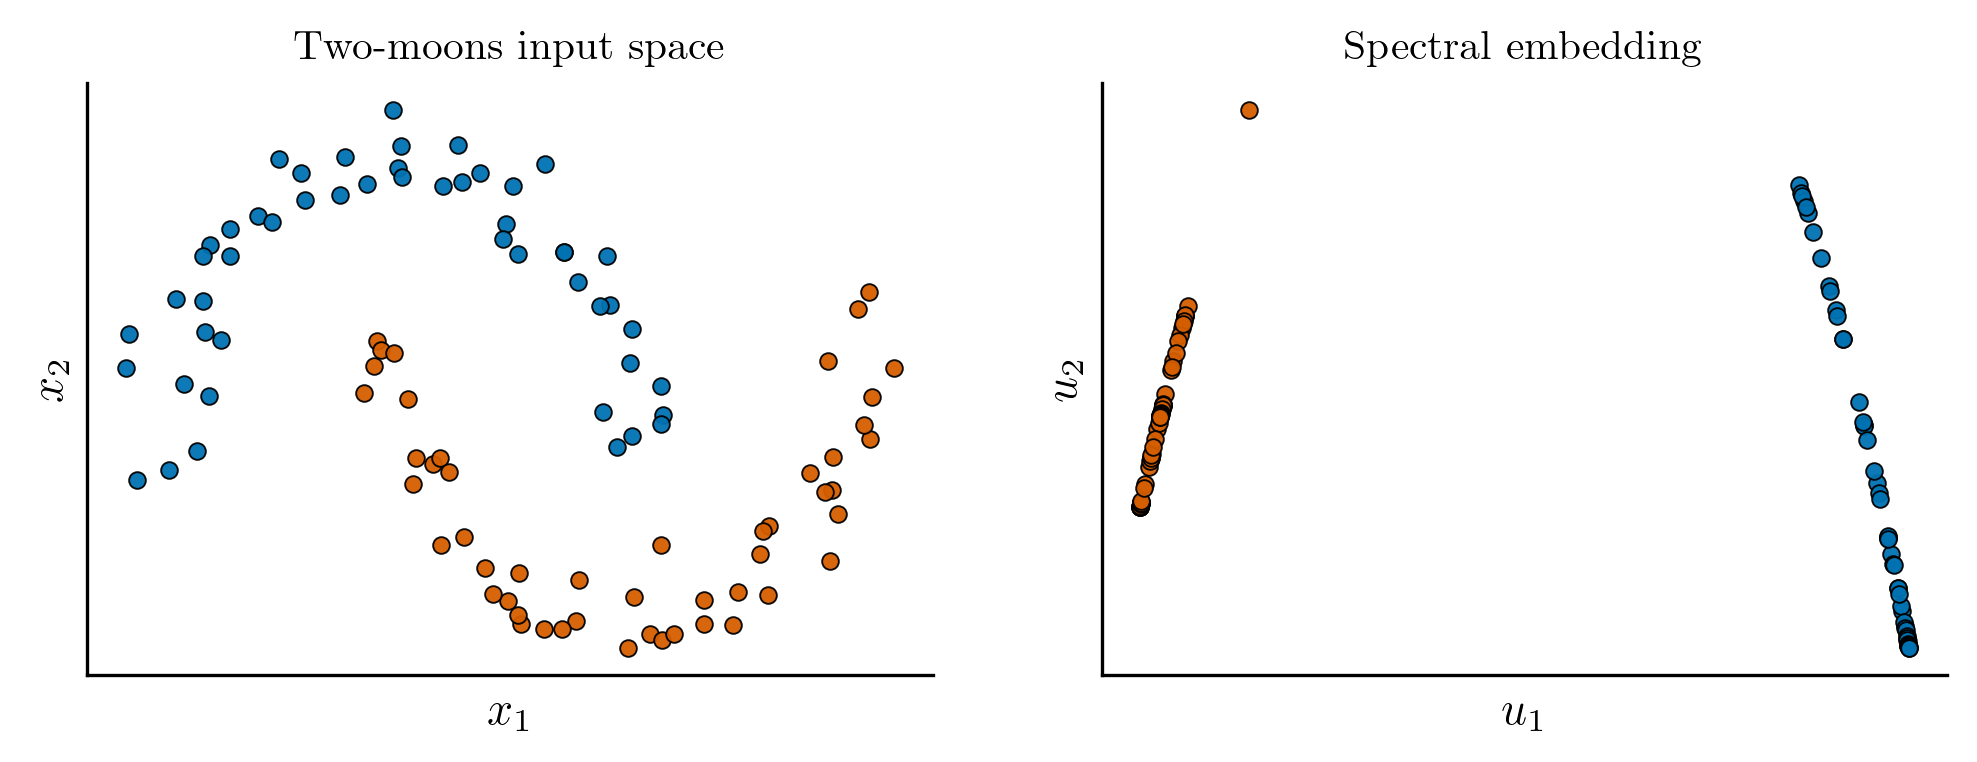

In [73]:
X, y = make_moons(n_samples=100, noise=0.1, shuffle=False, random_state=13)
W_knn = knn_graph(X, k=10)

d = np.asarray(W_knn.sum(axis=1)).ravel() if sparse.isspmatrix(W_knn) else np.asarray(W_knn @ np.ones(n)).ravel()
d = np.maximum(d, 1e-12)
dinv2 = 1.0 / np.sqrt(d)
Dinv2 = sparse.diags(dinv2, format="csr")
A = Dinv2 @ W_knn @ Dinv2

evalsA, evecs = sparse.linalg.eigsh(A, k=2, which="LA")
evals = 1 - evalsA

norms = np.sum(evecs*evecs, axis=1)
row_scale = (norms + 1e-12) ** (-0.5)
evecs = evecs * row_scale[:, None]

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), dpi=300)

fig.patch.set_facecolor('white')
for ax in axes: ax.set_facecolor('white')

plot_graph_from_adjacency(
    W=W_knn,
    X=X,
    labels=y,
    filename=None,
    legend=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    xticks=False,
    yticks=False,
    edge_color="#2A2A2A",
    edge_alpha=0,
    node_size=16,
    scale_edge_width_by_weight=True,
    ax = axes[0]
)

plot_graph_from_adjacency(
    W=W_knn,
    X=evecs,
    labels=y,
    filename=None,
    legend=False,
    xlabel=r"$u_1$",
    ylabel=r"$u_2$",
    xticks=False,
    yticks=False,
    edge_color="#2A2A2A",
    edge_alpha=0,
    node_size=16,
    scale_edge_width_by_weight=True,
    ax = axes[1]
)

axes[0].set_title('Two-moons input space', fontsize=10)
axes[1].set_title('Spectral embedding', fontsize=10)

for ax in axes:
    ax.set_box_aspect(0.7)
    ax.set_aspect("auto")
    
plt.savefig(f"charts/graph_construction/tm_spectral_embedding.pdf", bbox_inches="tight")
plt.savefig(f"charts/graph_construction/tm_spectral_embedding.png", bbox_inches="tight")
    
plt.show()